# 01 — Mic Array Geometry

Visualize and compare candidate mic array patterns for a 96-mic, 300 mm aperture acoustic camera.

**Design targets:**
- 96 microphones total
- 300 mm diameter aperture (150 mm radius)
- ~21 mm minimum mic spacing (Nyquist criterion at 8 kHz: λ/2 = 343/16000 ≈ 21.4 mm)
- 25 mm inner keep-out (center reserved for camera/mount)

**Patterns compared:**
1. Underbrink 8-arm × 12 mics (primary candidate)
2. Underbrink 6-arm × 16 mics (alternative)
3. Vogel/Fermat golden-angle spiral (benchmark)
4. Concentric rings (baseline)
5. Regular grid (baseline)

**Underbrink parameter sweeps:** arms H ∈ {4, 6, 8, 12, 16} and spiral pitch angle ∈ {10°..40°}.

---
**Note on Underbrink spacing:**  
Mics must be placed at equal arc-length intervals along each spiral arm, not at equal angular or
equal log-radius steps. Equal log-radius spacing (geomspace) clusters mics very tightly near the
inner radius (adjacent-mic distance ≈ r_min × Δθ → small). Equal arc-length spacing gives uniform
inter-mic distance along the arm and is consistent with the Underbrink patent.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

C          = 343.0   # speed of sound (m/s)
R_MAX      = 0.150   # outer radius: 150 mm → 300 mm aperture
R_MIN      = 0.025   # inner radius: 25 mm keep-out for camera mount
N_MICS     = 96
F_MAX      = 8000    # target upper frequency (Hz)
D_NYQUIST  = C / (2 * F_MAX)  # 21.4 mm — max spacing for alias-free at F_MAX

## Array Geometry Functions

In [10]:
def underbrink_array(n_arms, n_per_arm, r_min=R_MIN, r_max=R_MAX, spiral_angle_deg=22.0):
    """
    Underbrink multi-arm logarithmic spiral array (US Patent 6,089,671).

    Each arm is a log-spiral r = r_min * exp(b * theta).  Mics are placed at
    EQUAL ARC-LENGTH intervals along each arm — not at equal angular or equal
    log-radius steps, which would pack mics too tightly near r_min.

    Arc-length of log-spiral from theta=0 to theta:
        s(theta) = r_min * sqrt(1 + b^2) / b * (exp(b*theta) - 1)
    Invert:
        theta(s) = log(1 + b*s / (r_min * sqrt(1 + b^2))) / b

    Arms are evenly rotated by 2*pi/n_arms.
    """
    b   = 1.0 / np.tan(np.radians(spiral_angle_deg))   # log-spiral growth rate
    sq  = np.sqrt(1.0 + b**2)

    # Total arc length of one arm
    theta_max  = np.log(r_max / r_min) / b
    S_total    = r_min * sq / b * (np.exp(b * theta_max) - 1.0)

    # Equal arc-length steps
    s_steps  = np.linspace(0.0, S_total, n_per_arm)
    theta_arm = np.log(1.0 + b * s_steps / (r_min * sq)) / b
    r_arm     = r_min * np.exp(b * theta_arm)

    xs, ys = [], []
    for h in range(n_arms):
        offset = h * 2.0 * np.pi / n_arms
        theta  = theta_arm + offset
        xs.append(r_arm * np.cos(theta))
        ys.append(r_arm * np.sin(theta))

    return np.concatenate(xs), np.concatenate(ys)


def vogel_spiral(n_mics=N_MICS, r_max=R_MAX):
    """Vogel/Fermat golden-angle spiral.  Uniform area density."""
    golden_angle = np.radians(137.508)
    n = np.arange(1, n_mics + 1)
    r = np.sqrt(n / n_mics) * r_max
    theta = n * golden_angle
    return r * np.cos(theta), r * np.sin(theta)


def concentric_rings(n_mics=N_MICS, r_max=R_MAX, n_rings=6):
    """Concentric uniform rings; mic count proportional to circumference."""
    radii   = np.linspace(r_max / n_rings, r_max, n_rings)
    weights = radii / radii.sum()
    counts  = np.round(weights * n_mics).astype(int)
    counts[-1] += n_mics - counts.sum()

    xs, ys = [], []
    for r, count in zip(radii, counts):
        angles = np.linspace(0, 2 * np.pi, count, endpoint=False)
        xs.append(r * np.cos(angles))
        ys.append(r * np.sin(angles))
    return np.concatenate(xs), np.concatenate(ys)


def regular_grid(n_mics_target=N_MICS, r_max=R_MAX):
    """Square grid inscribed in a circle."""
    spacing = np.sqrt(np.pi * r_max**2 / n_mics_target)
    xs, ys = [], []
    for x in np.arange(-r_max, r_max + spacing, spacing):
        for y in np.arange(-r_max, r_max + spacing, spacing):
            if x**2 + y**2 <= r_max**2:
                xs.append(x)
                ys.append(y)
    return np.array(xs), np.array(ys)

## Analysis Utilities

In [11]:
def nearest_neighbor_distances(x, y):
    """Per-mic nearest-neighbor distances."""
    pos = np.column_stack([x, y])
    D   = cdist(pos, pos)
    np.fill_diagonal(D, np.inf)
    return D.min(axis=1)


def array_stats(name, x, y):
    nn    = nearest_neighbor_distances(x, y)
    d_min = nn.min()
    d_max = nn.max()
    return {
        "Array":                name,
        "N":                    len(x),
        "Min spacing (mm)":     round(d_min * 1e3, 1),
        "Median spacing (mm)":  round(np.median(nn) * 1e3, 1),
        "Max spacing (mm)":     round(d_max * 1e3, 1),
        "Alias-free ceiling":   f"{C / (2 * d_min):.0f} Hz",
        "Max alias-free at":    f"{C / (2 * d_max):.0f} Hz (sparsest pair)",
    }


def plot_array(ax, x, y, title):
    ax.scatter(x * 1e3, y * 1e3, s=12, color='royalblue', zorder=3)
    ax.add_patch(plt.Circle((0, 0), R_MAX * 1e3,
                             fill=False, linestyle='--', color='gray', alpha=0.5))
    ax.add_patch(plt.Circle((0, 0), R_MIN * 1e3,
                             fill=True, color='lightgray', alpha=0.4, zorder=2))
    margin = R_MAX * 1e3 * 1.15
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)
    ax.set_title(f"{title}  (N={len(x)})", fontsize=10)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

## Generate Arrays

In [12]:
arrays = {
    "Underbrink 8×12": underbrink_array(8, 12),
    "Underbrink 6×16": underbrink_array(6, 16),
    "Vogel/Fermat":    vogel_spiral(),
    "Concentric Rings": concentric_rings(),
    "Regular Grid":    regular_grid(),
}

## Array Layout Visualization

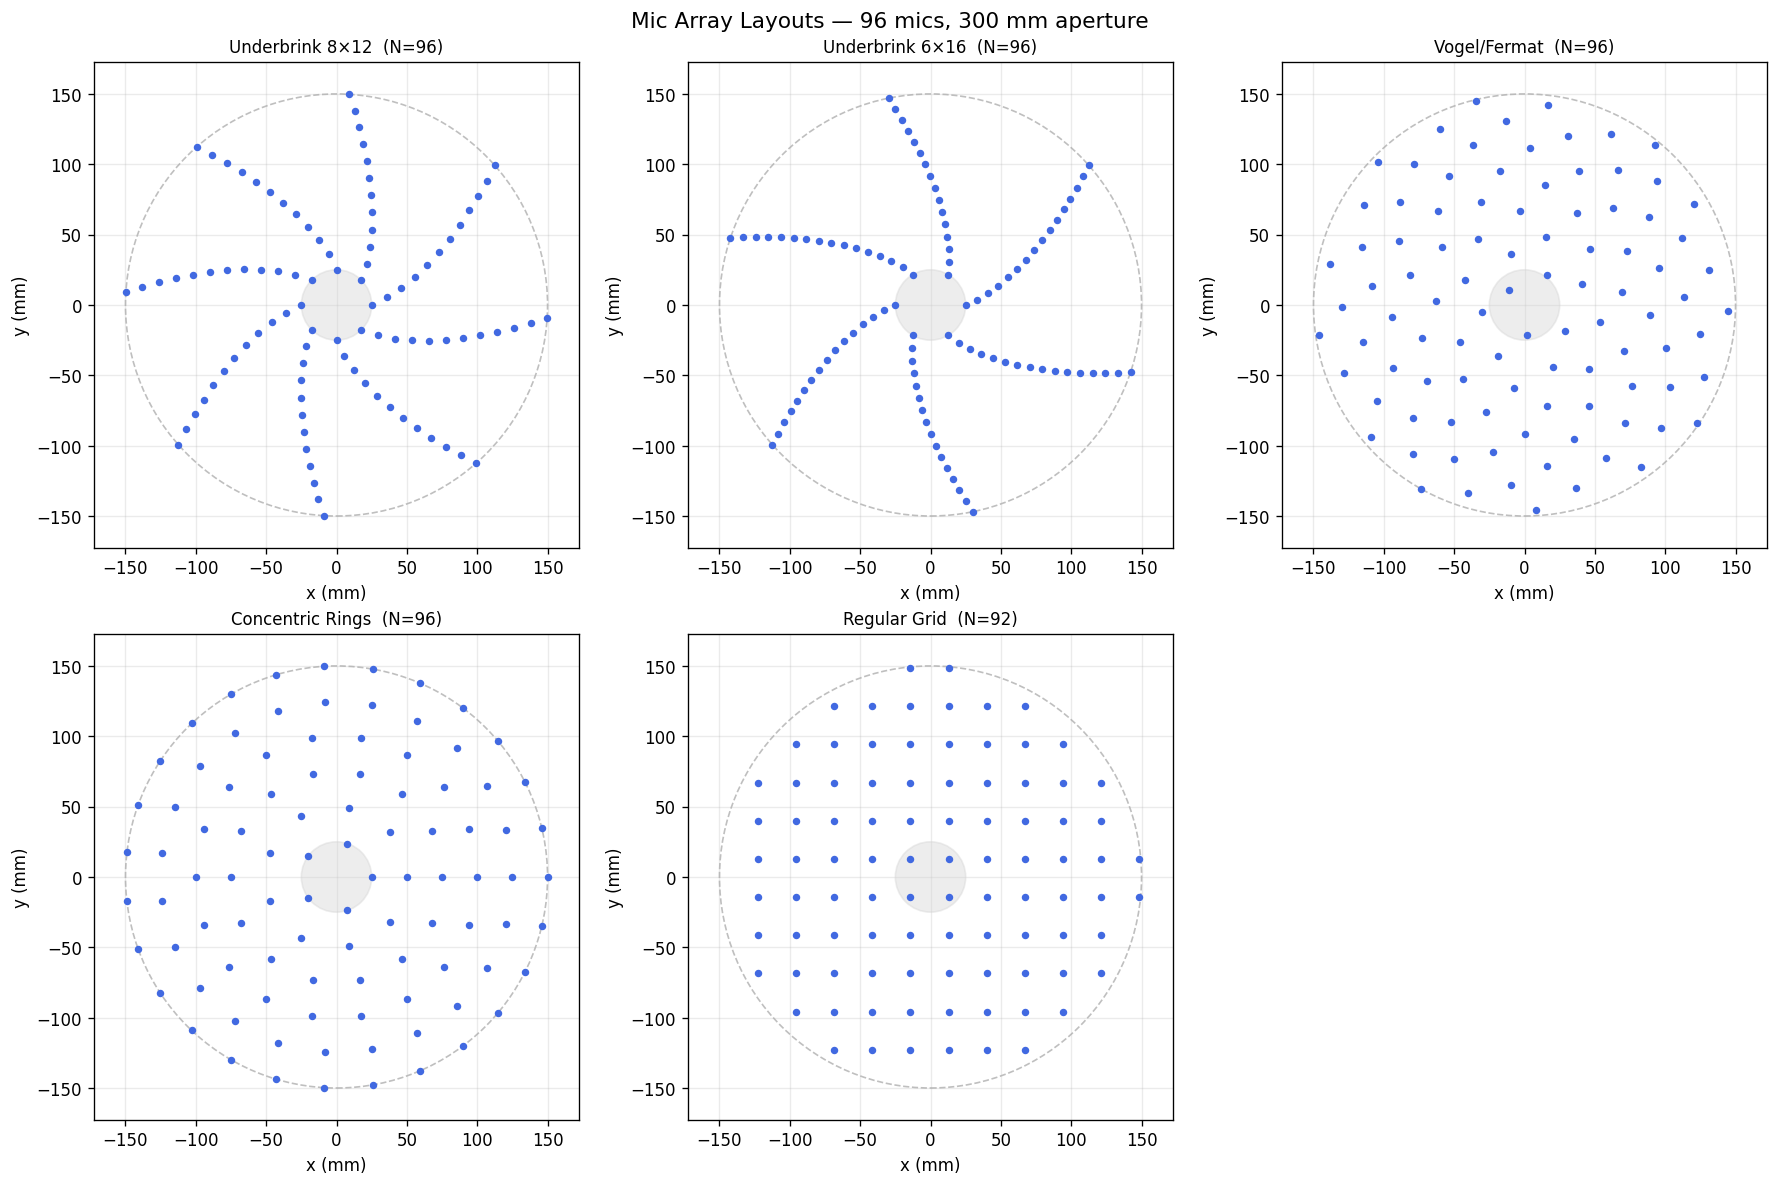

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, (x, y)) in zip(axes, arrays.items()):
    plot_array(ax, x, y, name)

axes[-1].set_visible(False)
fig.suptitle("Mic Array Layouts — 96 mics, 300 mm aperture", fontsize=13)
plt.tight_layout()
plt.savefig("array_layouts.png", dpi=150, bbox_inches='tight')
plt.show()

## Nearest-Neighbor Spacing Distributions

Red dashed line = Nyquist limit at 8 kHz (21.4 mm).  
For irregular arrays, the min spacing sets the alias-free **ceiling** (densest pair),
and the max spacing sets how sparse the array is at low frequencies.

ValueError: Too many bins for data range. Cannot create 20 finite-sized bins.

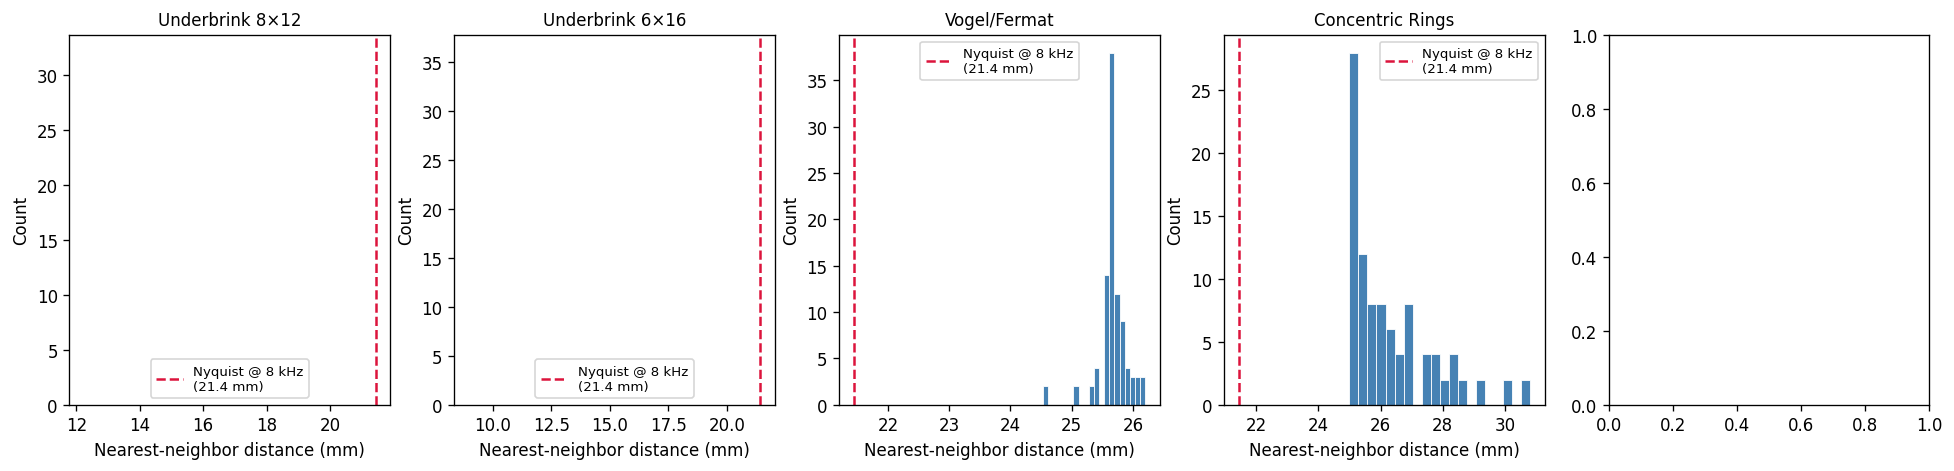

In [14]:
fig, axes = plt.subplots(1, len(arrays), figsize=(20, 4), sharey=False)

for ax, (name, (x, y)) in zip(axes, arrays.items()):
    nn = nearest_neighbor_distances(x, y) * 1e3  # mm
    ax.hist(nn, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(D_NYQUIST * 1e3, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Nyquist @ {F_MAX//1000} kHz\n({D_NYQUIST*1e3:.1f} mm)')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Nearest-neighbor distance (mm)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Nearest-Neighbor Spacing Distributions", fontsize=12)
plt.tight_layout()
plt.savefig("spacing_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics

In [15]:
rows = [array_stats(name, x, y) for name, (x, y) in arrays.items()]
pd.DataFrame(rows).set_index("Array")

,N,Min spacing (mm),Median spacing (mm),Max spacing (mm),Alias-free ceiling,Max alias-free at
Array,,,,,,
Underbrink 8×12,96,12.2,12.3,12.3,14006 Hz,13994 Hz (sparsest pair)
Underbrink 6×16,96,9.0,9.0,9.0,19092 Hz,19082 Hz (sparsest pair)
Vogel/Fermat,96,24.5,25.7,26.2,6993 Hz,6545 Hz (sparsest pair)
Concentric Rings,96,25.0,25.8,30.8,6860 Hz,5567 Hz (sparsest pair)
Regular Grid,92,27.1,27.1,27.1,6320 Hz,6320 Hz (sparsest pair)


## Underbrink Parameter Sweep — Number of Arms

Fixed spiral angle = 22°.  Total mic count varies slightly where 96 is not evenly divisible.

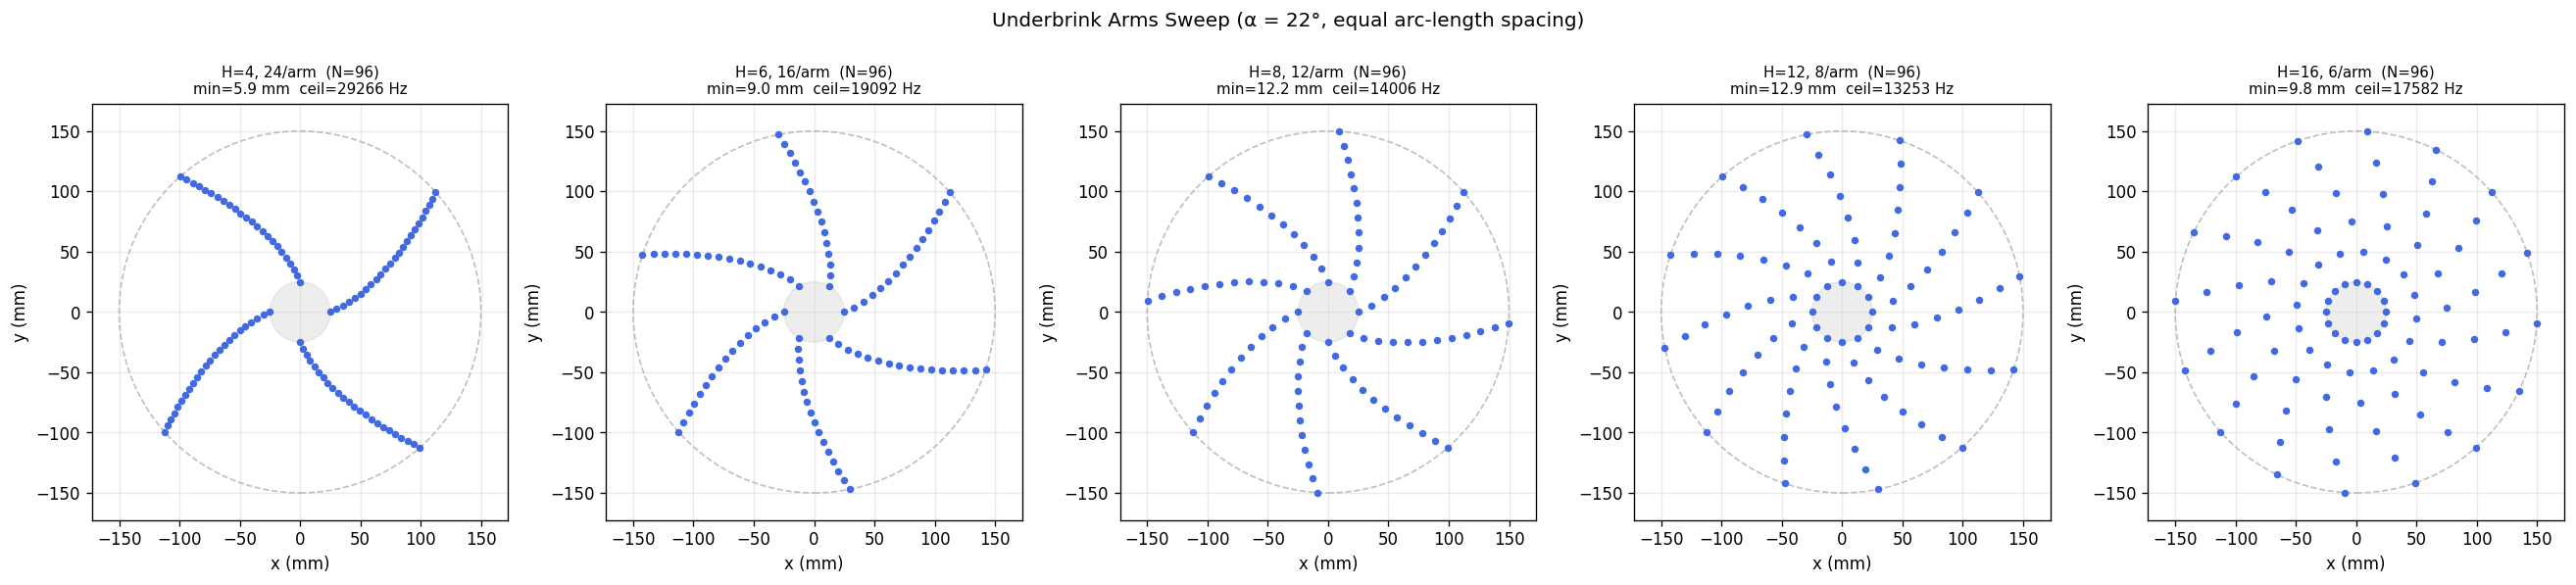

In [16]:
arm_configs = [(4, 24), (6, 16), (8, 12), (12, 8), (16, 6)]

fig, axes = plt.subplots(1, len(arm_configs), figsize=(22, 5))

for ax, (h, n) in zip(axes, arm_configs):
    x, y = underbrink_array(h, n)
    nn   = nearest_neighbor_distances(x, y)
    d_min = nn.min() * 1e3
    plot_array(ax, x, y, f"H={h}, {n}/arm")
    ax.set_title(
        f"H={h}, {n}/arm  (N={h*n})\n"
        f"min={d_min:.1f} mm  ceil={C/(2*nn.min()):.0f} Hz",
        fontsize=9
    )

fig.suptitle("Underbrink Arms Sweep (α = 22°, equal arc-length spacing)", fontsize=12)
plt.tight_layout()
plt.savefig("underbrink_arms_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

In [18]:
rows = [array_stats(f"H={h}, {n}/arm", *underbrink_array(h, n)) for h, n in arm_configs]
pd.DataFrame(rows).set_index("Array")

,N,Min spacing (mm),Median spacing (mm),Max spacing (mm),Alias-free ceiling,Max alias-free at
Array,,,,,,
"H=4, 24/arm",96,5.9,5.9,5.9,29266 Hz,29258 Hz (sparsest pair)
"H=6, 16/arm",96,9.0,9.0,9.0,19092 Hz,19082 Hz (sparsest pair)
"H=8, 12/arm",96,12.2,12.3,12.3,14006 Hz,13994 Hz (sparsest pair)
"H=12, 8/arm",96,12.9,19.3,19.3,13253 Hz,8906 Hz (sparsest pair)
"H=16, 6/arm",96,9.8,26.9,27.0,17582 Hz,6362 Hz (sparsest pair)


## Underbrink Spiral Angle Sweep

Fixed H=8, 12 mics/arm.  Smaller α = tighter spiral (mics cluster near outer edge);
larger α = looser spiral (mics spread more uniformly).

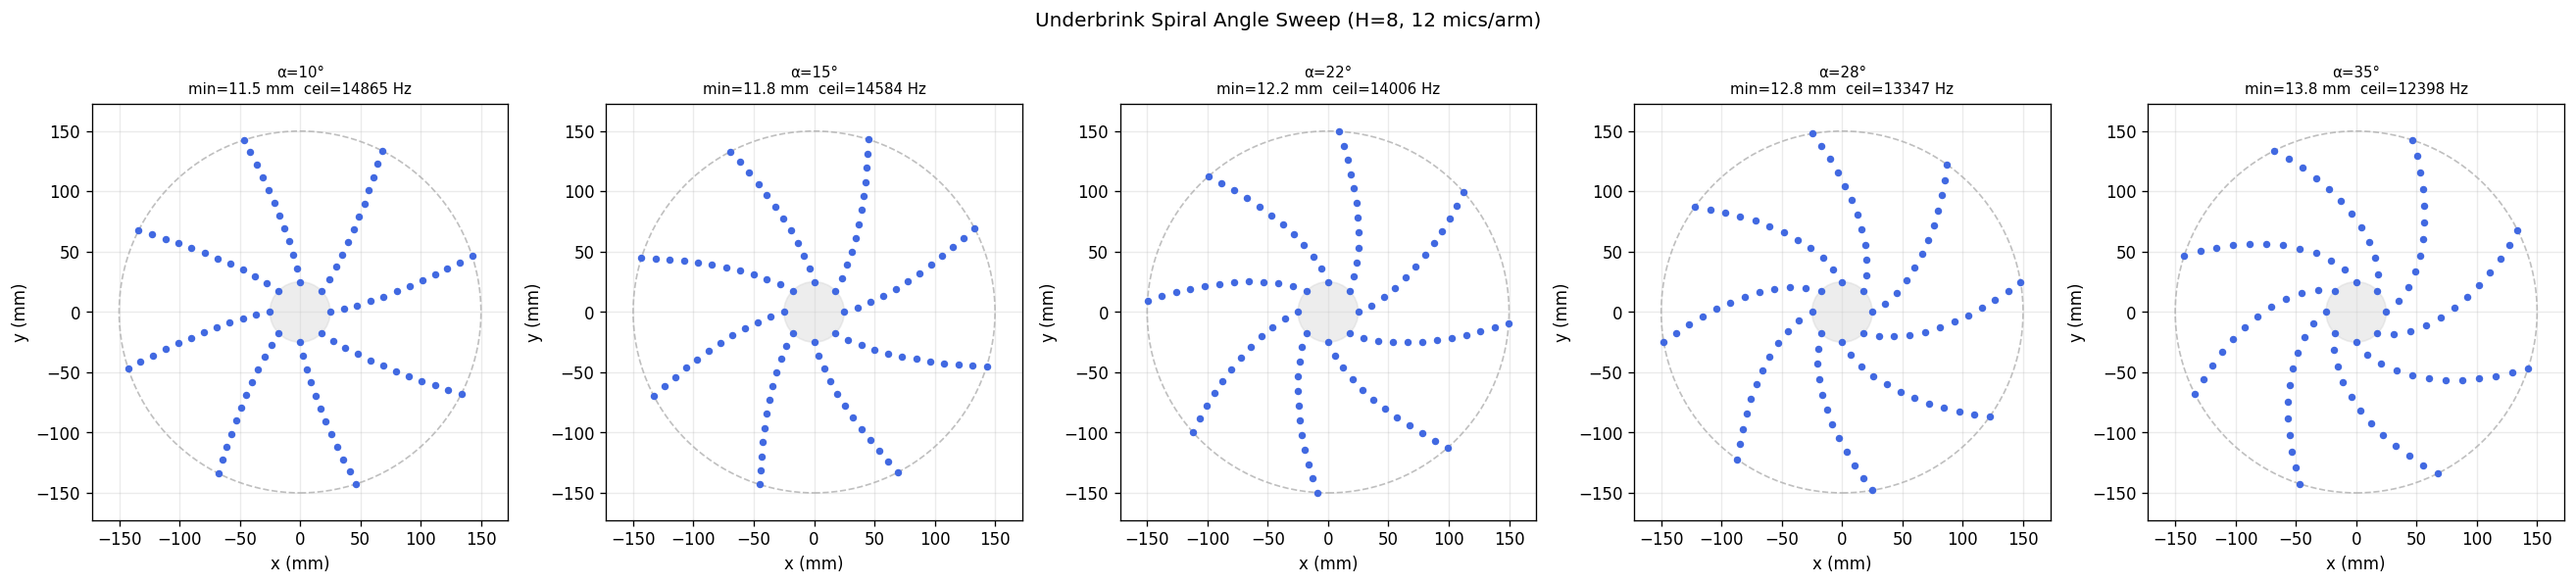

In [19]:
spiral_angles = [10, 15, 22, 28, 35]

fig, axes = plt.subplots(1, len(spiral_angles), figsize=(22, 5))

for ax, angle in zip(axes, spiral_angles):
    x, y = underbrink_array(8, 12, spiral_angle_deg=angle)
    nn   = nearest_neighbor_distances(x, y)
    d_min = nn.min() * 1e3
    plot_array(ax, x, y, f"α={angle}°")
    ax.set_title(
        f"α={angle}°\nmin={d_min:.1f} mm  ceil={C/(2*nn.min()):.0f} Hz",
        fontsize=9
    )

fig.suptitle("Underbrink Spiral Angle Sweep (H=8, 12 mics/arm)", fontsize=12)
plt.tight_layout()
plt.savefig("underbrink_angle_sweep.png", dpi=150, bbox_inches='tight')
plt.show()

## Minimum & Median Spacing vs. Spiral Angle (continuous)

Find the angle that maximises min spacing while keeping all mics within the aperture.

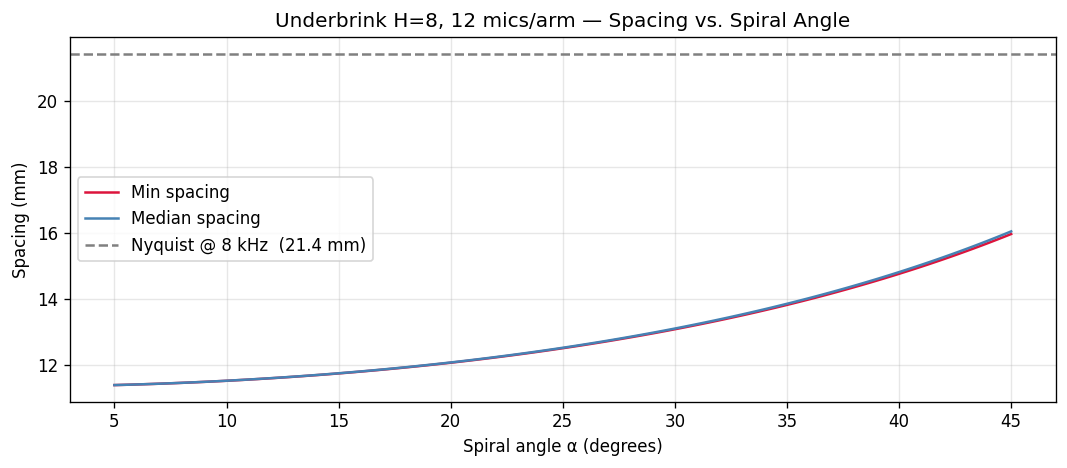

Peak min-spacing at α = 45.0°:  16.0 mm  (alias-free to 10734 Hz)


In [20]:
angles   = np.linspace(5, 45, 120)
d_mins   = []
d_meds   = []

for angle in angles:
    x, y = underbrink_array(8, 12, spiral_angle_deg=angle)
    nn   = nearest_neighbor_distances(x, y) * 1e3
    d_mins.append(nn.min())
    d_meds.append(np.median(nn))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(angles, d_mins, label='Min spacing', color='crimson')
ax.plot(angles, d_meds, label='Median spacing', color='steelblue')
ax.axhline(D_NYQUIST * 1e3, color='gray', linestyle='--',
           label=f'Nyquist @ {F_MAX//1000} kHz  ({D_NYQUIST*1e3:.1f} mm)')
ax.set_xlabel("Spiral angle α (degrees)")
ax.set_ylabel("Spacing (mm)")
ax.set_title("Underbrink H=8, 12 mics/arm — Spacing vs. Spiral Angle")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("underbrink_angle_vs_spacing.png", dpi=150, bbox_inches='tight')
plt.show()

best_idx = np.argmax(d_mins)
print(f"Peak min-spacing at α = {angles[best_idx]:.1f}°:  {d_mins[best_idx]:.1f} mm  "
      f"(alias-free to {C / (2 * d_mins[best_idx] * 1e-3):.0f} Hz)")

## Arms × Spiral-Angle Grid Search

Two-dimensional sweep over H ∈ {4, 6, 8, 12, 16} and α ∈ [10°, 40°].
Colour = min spacing (mm).  Target: maximise min spacing while keeping it ≤ D_NYQUIST
(i.e., alias-free to at least 8 kHz from the densest pair, with some headroom above).

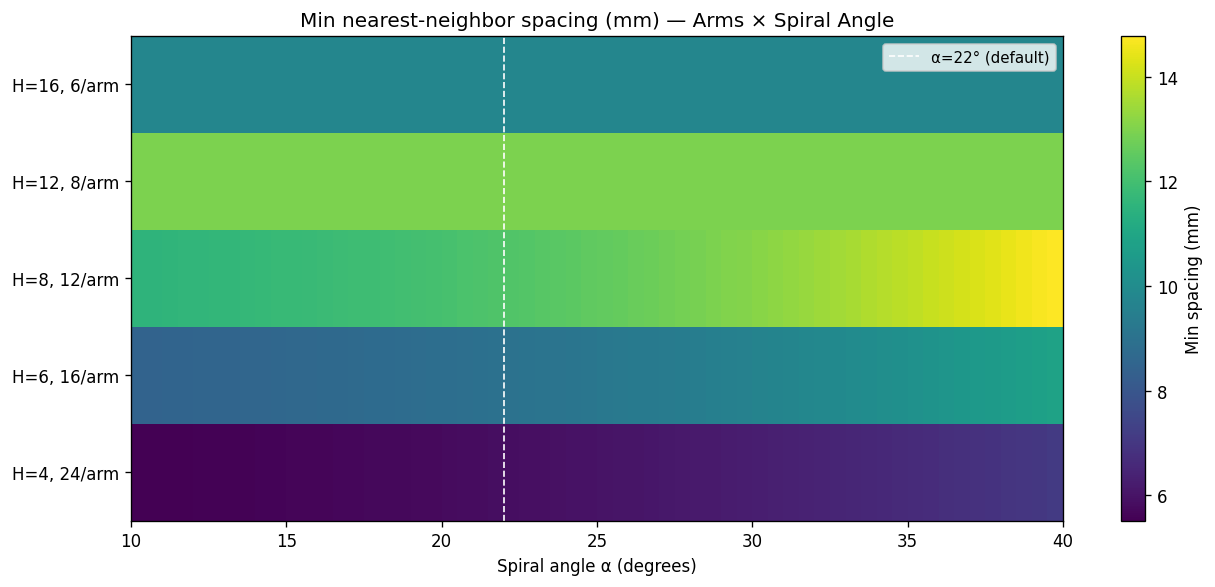

Config                 Best α    Min spacing    Alias-free ceil
-----------------------------------------------------------------
H=4, 24/arm          40.0°          7.1 mm            24201 Hz
H=6, 16/arm          40.0°         10.9 mm            15803 Hz
H=8, 12/arm          40.0°         14.8 mm            11609 Hz
H=12, 8/arm          10.0°         12.9 mm            13253 Hz
H=16, 6/arm          10.0°          9.8 mm            17582 Hz


In [21]:
arm_options   = [4, 6, 8, 12, 16]
angle_options = np.linspace(10, 40, 60)

# Build config list that keeps N_MICS as close to 96 as possible
configs = {h: 96 // h for h in arm_options}   # n_per_arm for each H

grid = np.zeros((len(arm_options), len(angle_options)))

for i, h in enumerate(arm_options):
    n = configs[h]
    for j, angle in enumerate(angle_options):
        x, y = underbrink_array(h, n, spiral_angle_deg=angle)
        nn   = nearest_neighbor_distances(x, y)
        grid[i, j] = nn.min() * 1e3

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(grid, aspect='auto', origin='lower',
               extent=[angle_options[0], angle_options[-1],
                       -0.5, len(arm_options) - 0.5],
               cmap='viridis')
ax.set_yticks(range(len(arm_options)))
ax.set_yticklabels([f"H={h}, {configs[h]}/arm" for h in arm_options])
ax.set_xlabel("Spiral angle α (degrees)")
ax.set_title("Min nearest-neighbor spacing (mm) — Arms × Spiral Angle")
fig.colorbar(im, ax=ax, label="Min spacing (mm)")
ax.axvline(22, color='white', linestyle='--', linewidth=1, label='α=22° (default)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("underbrink_grid_search.png", dpi=150, bbox_inches='tight')
plt.show()

# Print best per row
print(f"{'Config':<20} {'Best α':>8} {'Min spacing':>14} {'Alias-free ceil':>18}")
print("-" * 65)
for i, h in enumerate(arm_options):
    j   = np.argmax(grid[i])
    d   = grid[i, j]
    alp = angle_options[j]
    print(f"H={h}, {configs[h]}/arm        {alp:>6.1f}°   {d:>10.1f} mm   {C/(2*d*1e-3):>14.0f} Hz")